In [11]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from pipeline.data_pipeline import MarketDataPipeline
from analysis.orchestrator import AnalysisOrchestrator
from training.orchestrator import TrainingOrchestrator
from config.config import TRAINING_CONFIG, RUN_ID
from backtest.backtest_orchestrator import BacktestOrchestrator
from datetime import datetime, date, timedelta
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
TICKERS = [

    'PG',    # Procter & Gamble
    'KO',    # Coca-Cola
    'PEP',   # PepsiCo
    'WMT',   # Walmart
    'COST',  # Costco
    'MDLZ',  # Mondelez
    'CL',    # Colgate-Palmolive
    'MO',    # Altria
    'PM',    # Philip Morris
    'KMB',   # Kimberly-Clark

]

config = {
    "experiment_name": "test_experiment",
    "run_id": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "horizon": 1, #months
    "benchmark": '^GSPC',
    "tickers": TICKERS,
    "strategy": 'long_only',
    "model": {
        "model_type": "gradient_boosting",
        "hyperparams": {
            "n_estimators": 100,
            "learning_rate": 0.01
        }
    },
    "training": {
        "output_dir": "../training/artifacts"
    },
    "metrics": [
        "mse",
        "r2",
        "rank_ic"
    ]
}

In [4]:
data_pipeline = MarketDataPipeline(tickers=config['tickers'],run_id=config['run_id'])
training_pipeline = TrainingOrchestrator(config)

2026-03-01 21:24:22,033 | INFO | test_experiment | Initialized TrainingOrchestrator | Experiment=test_experiment | Run=20260301_212349


In [5]:
output_dir = data_pipeline.run()


2026-03-01 21:24:23,477 | INFO | MarketDataPipeline | Fetching raw market data...
2026-03-01 21:24:23,478 | INFO | data.fetch_data | Fetching data for ticker=PG
2026-03-01 21:24:24,379 | INFO | data.fetch_data | Fetching data for ticker=KO
2026-03-01 21:24:24,924 | INFO | data.fetch_data | Fetching data for ticker=PEP
2026-03-01 21:24:25,080 | INFO | data.fetch_data | Fetching data for ticker=WMT
2026-03-01 21:24:25,224 | INFO | data.fetch_data | Fetching data for ticker=COST
2026-03-01 21:24:25,333 | INFO | data.fetch_data | Fetching data for ticker=MDLZ
2026-03-01 21:24:25,436 | INFO | data.fetch_data | Fetching data for ticker=CL
2026-03-01 21:24:26,037 | INFO | data.fetch_data | Fetching data for ticker=MO
2026-03-01 21:24:26,195 | INFO | data.fetch_data | Fetching data for ticker=PM
2026-03-01 21:24:26,293 | INFO | data.fetch_data | Fetching data for ticker=KMB
2026-03-01 21:24:26,411 | INFO | data.fetch_data | Fetched data for 10 tickers (12,550 rows)
2026-03-01 21:24:26,411 | IN

                                        Open        High         Low  \
Date                      Ticker                                       
2021-03-02 00:00:00-05:00 CL       67.202625   67.566894   66.865015   
                          COST    315.921057  316.867807  310.931694   
                          KMB     106.788629  108.204369  106.613750   
                          KO       42.879746   43.499198   42.759298   
                          MDLZ     47.475291   47.748646   46.866861   

                                       Close    Volume  
Date                      Ticker                        
2021-03-02 00:00:00-05:00 CL       67.007164   4977000  
                          COST    310.969543   4660100  
                          KMB     107.538147   2413000  
                          KO       43.103436  11755100  
                          MDLZ     47.334206   7706500  
Building features for 10 tickers...


2026-03-01 21:24:27,176 | INFO | MarketDataPipeline | Adding labels...
2026-03-01 21:24:27,187 | INFO | MarketDataPipeline | Splitting data into 15 iterations...


Features built: 12,550 → 10,030 rows after dropping NaN
                                        Open        High         Low  \
Date                      Ticker                                       
2022-03-01 00:00:00-05:00 CL       69.963542   70.127094   68.809601   
                          COST    495.324645  504.764632  495.067171   
                          KMB     111.755048  112.435687  109.885422   
                          KO       55.147473   55.688832   54.588365   
                          MDLZ     58.553407   58.967848   57.778580   
...                                      ...         ...         ...   
2024-03-01 00:00:00-05:00 MO       35.145808   35.231738   34.879421   
                          PEP     154.778395  154.909833  153.266850   
                          PG      150.124422  151.055275  149.706484   
                          PM       82.622917   82.650509   81.730739   
                          WMT      57.552664   57.601603   56.965393   

       

2026-03-01 21:24:28,093 | INFO | MarketDataPipeline | Created 15 train/test splits.
2026-03-01 21:24:28,093 | INFO | MarketDataPipeline | Fetching live market snapshot...
2026-03-01 21:24:28,094 | INFO | data.fetch_data | Fetching data for ticker=PG
2026-03-01 21:24:28,113 | INFO | data.fetch_data | Fetching data for ticker=KO
2026-03-01 21:24:28,132 | INFO | data.fetch_data | Fetching data for ticker=PEP
2026-03-01 21:24:28,152 | INFO | data.fetch_data | Fetching data for ticker=WMT
2026-03-01 21:24:28,174 | INFO | data.fetch_data | Fetching data for ticker=COST
2026-03-01 21:24:28,192 | INFO | data.fetch_data | Fetching data for ticker=MDLZ
2026-03-01 21:24:28,209 | INFO | data.fetch_data | Fetching data for ticker=CL
2026-03-01 21:24:28,227 | INFO | data.fetch_data | Fetching data for ticker=MO
2026-03-01 21:24:28,246 | INFO | data.fetch_data | Fetching data for ticker=PM
2026-03-01 21:24:28,264 | INFO | data.fetch_data | Fetching data for ticker=KMB
2026-03-01 21:24:28,286 | INFO |

Saved 15 splits to ..\data\datasets\20260301_212349


2026-03-01 21:24:28,309 | INFO | data.clean | Market data cleaned: 12,550 → 12,550 rows


Building features for 10 tickers...
Features built: 12,550 → 10,030 rows after dropping NaN


2026-03-01 21:24:28,915 | INFO | MarketDataPipeline | Live snapshot saved.


In [6]:
training_pipeline.run_pipeline(output_dir)


2026-03-01 21:24:46,554 | INFO | test_experiment | Split 0 | {'mse': 0.11354726696380757, 'r2': -0.37633050865221285, 'rank_ic': np.float64(-0.0643290814162534)}
2026-03-01 21:25:02,401 | INFO | test_experiment | Split 1 | {'mse': 0.0939155109451012, 'r2': -0.13836982963759037, 'rank_ic': np.float64(0.15687683996606352)}
2026-03-01 21:25:20,229 | INFO | test_experiment | Split 2 | {'mse': 0.07966724084575859, 'r2': 0.03433647459686562, 'rank_ic': np.float64(0.3119177500075231)}
2026-03-01 21:25:34,171 | INFO | test_experiment | Split 3 | {'mse': 0.08307160302956874, 'r2': -0.006928521570530366, 'rank_ic': np.float64(0.30490047714494717)}
2026-03-01 21:25:47,134 | INFO | test_experiment | Split 4 | {'mse': 0.06262273208051289, 'r2': 0.240936580842268, 'rank_ic': np.float64(0.52588368100698)}
2026-03-01 21:26:01,068 | INFO | test_experiment | Split 5 | {'mse': 0.09155264459496541, 'r2': -0.10972902539352014, 'rank_ic': np.float64(0.21560168548703804)}
2026-03-01 21:26:15,042 | INFO | tes

In [7]:
analysis_pipeline = AnalysisOrchestrator(training_pipeline)
analysis_pipeline.run_full_analysis()



🚀 ==================================================================
STARTING COMPREHENSIVE MODEL ANALYSIS

RUNNING STATISTICAL VALIDATION
STATISTICAL VALIDATION REPORT - RANK_IC

📊 DESCRIPTIVE STATISTICS
   Mean:                0.2269
   Std Dev:             0.1567
   Median:              0.2200
   Information Ratio:   1.4481

🎯 HYPOTHESIS TEST (H0: rank_ic = 0)
   T-statistic:         5.6085
   P-value:             0.0001
   95% CI:            [0.1401, 0.3137]
   ✅ SIGNIFICANT at α=0.05

📈 CONSISTENCY
   Positive splits:     86.7%

🎲 COMPARISON VS SHUFFLE TEST
   T-statistic:         4.7569
   P-value:             0.0001
   ✅ BEATS RANDOM at α=0.05

💡 INTERPRETATION
   ✅ Model demonstrates statistically significant predictive power
   ✅ Performance significantly better than random
   ✅ Strong information ratio (>1.0)
Results exported to ..\training\artifacts\test_experiment\20260301_212349\analysis\validation_results.json

RUNNING MODEL DIAGNOSTICS
MODEL DIAGNOSTICS REPORT

📊 PERFOR

{'validator': <analysis.validators.StatisticalValidator at 0x1e2885531a0>,
 'diagnostics': <analysis.diagnostics.ModelDiagnostics at 0x1e2885533b0>,
 'regime_analyzer': <analysis.diagnostics.RegimeAnalyser at 0x1e28a6c39b0>,
 'feature_analyser': <analysis.feature_analysis.FeatureAnalyser at 0x1e2886e7380>}

In [9]:
backtest_orch = BacktestOrchestrator(config)
backtest_orch.run()

C:\Projects\MlSignalService\backtest\data_loaders.py:17: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  pred_data['Date'] = pd.to_datetime(pred_data['Date'])
2026-03-01 21:35:46,525 | INFO | data.fetch_data | Fetching data for ticker=CL
2026-03-01 21:35:46,710 | INFO | data.fetch_data | Fetching data for ticker=COST
2026-03-01 21:35:46,842 | INFO | data.fetch_data | Fetching data for ticker=KMB
2026-03-01 21:35:46,948 | INFO | data.fetch_data | Fetching data for ticker=KO
2026-03-01 21:35:47,078 | INFO | data.fetch_data | Fetching data for ticker=MDLZ
2026-03-01 21:35:47,155 | INFO | data.fetch_data | Fetching data for ticker=MO
2026-03-01 21:35:47,286 | INFO | data.fetch_data | Fetching data for ticker=PEP
2026-03-

<Figure size 1000x600 with 0 Axes>

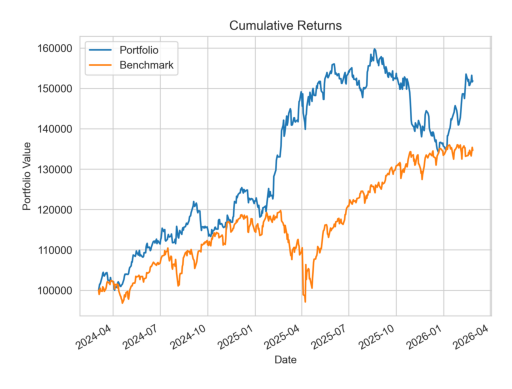

In [14]:
path = '../training/artifacts/' + config['experiment_name'] + '/' + config['run_id'] + '/backtest/cumulative_returns.png'

img = mpimg.imread(path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [19]:
path = '../training/artifacts/' + config['experiment_name'] + '/' + config['run_id'] + '/predictions/live_signal.csv'
predictions = pd.read_csv(path)

predictions['Date'] = pd.to_datetime(predictions['Date'])

latest_date = predictions['Date'].max()

latest_predictions = (
    predictions[predictions['Date'] == latest_date][['Date', 'Ticker', 'signal']]
    .sort_values(by='signal', ascending=False)
    .reset_index(drop=True)
)

latest_predictions

C:\Users\user\AppData\Local\Temp\ipykernel_13120\4230025566.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  predictions['Date'] = pd.to_datetime(predictions['Date'])


,Date,Ticker,signal
0,2026-02-27 00:00:00-05:00,WMT,0.835285
1,2026-02-27 00:00:00-05:00,KO,0.625582
2,2026-02-27 00:00:00-05:00,MDLZ,0.581698
3,2026-02-27 00:00:00-05:00,PG,0.528232
4,2026-02-27 00:00:00-05:00,MO,0.397316
5,2026-02-27 00:00:00-05:00,PEP,0.353337
6,2026-02-27 00:00:00-05:00,COST,0.336760
7,2026-02-27 00:00:00-05:00,PM,0.315928
8,2026-02-27 00:00:00-05:00,CL,0.310882
9,2026-02-27 00:00:00-05:00,KMB,0.264715
